# Curvature correlation analysis

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from itertools import combinations
from matplotlib.colors import BoundaryNorm

## Parsing

In [2]:
INDEX_LIST_RE = re.compile(r"^\d+(,\d+)*$")

def parse_curvature_file(path: Path) -> pd.DataFrame:
    """Parse a '<key> : <value>' file into a DataFrame with columns:
    position, key_raw, key_set (frozenset of ints, or None), cardinality, value.
    """
    rows = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            key_raw, value_raw = line.rsplit(":", 1)
            key_raw = key_raw.strip()
            value = float(value_raw.strip())

            key_set = None
            cardinality = np.nan
            if INDEX_LIST_RE.match(key_raw):
                key_set = frozenset(int(x) for x in key_raw.split(","))
                cardinality = len(key_raw.split(","))

            rows.append({"position": len(rows), "key_raw": key_raw,
                         "key_set": key_set, "cardinality": cardinality,
                         "value": value})

    return pd.DataFrame(rows)

def resolve_label(name: str) -> str:
    """Accept 'OR_Dualcurvature', 'OR_Dualcurvature.txt', or a full path."""
    if name in parsed:
        return name
    stem = Path(name).stem
    if stem in parsed:
        return stem
    matches = [l for l in parsed if l.lower() == stem.lower()]
    if len(matches) == 1:
        return matches[0]
    raise KeyError(f"Unknown file {name!r}. Available: {sorted(parsed)}")

## Configuration

Point `DATA_DIR` at the folder containing the result files you want to correlate, and/or list specific files in `FILES`.

In [ ]:
DATA_DIR = Path(
    r"MY_PATH\clustering_ML\results\synthetic_data\uniform_cluster_id1\hyperedge"
)

# Explicit list (order controls the correlation matrix / scatter order below).
# Leave as None to auto-discover every .txt file in DATA_DIR.
FILES = [
    "Forman_curvature.txt",
    # "OR_Dual_curvature.txt",
    "OR_MMOT_curvature.txt",
]

if FILES is None:
    paths = sorted(DATA_DIR.glob("*.txt"))
else:
    paths = [DATA_DIR / name for name in FILES]

labels = [p.stem for p in paths]
parsed = {label: parse_curvature_file(p) for label, p in zip(labels, paths)}

for label, df in parsed.items():
    n_indexed = df["key_set"].notna().sum()
    print(f"{label}: {len(df)} rows, {n_indexed} with index-list keys")

for label, df in parsed.items():
    print(f"\n=== {label} ===")
    display(df.head())

Forman_curvature: 2028 rows, 2028 with index-list keys
OR_MMOT_curvature: 2028 rows, 2028 with index-list keys

=== Forman_curvature ===


,position,key_raw,key_set,cardinality,value
0,0,"0,335","(0, 335)",2,-2.0
1,1,"0,361","(0, 361)",2,-7.0
2,2,"1,330","(1, 330)",2,-5.0
3,3,"1,357","(1, 357)",2,-6.0
4,4,"1,939","(1, 939)",2,-11.0



=== OR_MMOT_curvature ===


,position,key_raw,key_set,cardinality,value
0,0,"0,335","(0, 335)",2,-0.893271
1,1,"0,361","(0, 361)",2,-0.750872
2,2,"1,330","(1, 330)",2,-0.792061
3,3,"1,357","(1, 357)",2,-1.089039
4,4,"1,939","(1, 939)",2,-1.190210


## Matching two files up into a DataFrame

In [106]:
def build_pair_dataframe(df_a: pd.DataFrame, df_b: pd.DataFrame,
                         name_a: str = "a", name_b: str = "b") -> pd.DataFrame:
    """Match rows of df_a and df_b on the index-list key, falling back to
    positional matching. Always returns columns: key, value_a, value_b.
    """
    usable = (
        df_a["key_set"].notna().all()
        and df_b["key_set"].notna().all()
        and not df_a["key_set"].duplicated().any()
        and not df_b["key_set"].duplicated().any()
    )

    if usable:
        left = df_a[["key_set", "cardinality", "value"]].rename(columns={"value": "value_a"})
        right = df_b[["key_set", "value"]].rename(columns={"value": "value_b"})
        merged = left.merge(right, on="key_set", how="inner").rename(columns={"key_set": "key"})
        ...
    else:
        ...
        merged = pd.DataFrame({
            "key": df_a["key_raw"].values,
            "cardinality": df_a["cardinality"].values,
            "value_a": df_a["value"].values,
            "value_b": df_b["value"].values,
        })

    return merged

## Scatter plot + correlation for a single pair

In [107]:
def correlate(name_a: str, name_b: str):
    a, b = resolve_label(name_a), resolve_label(name_b)
    df = build_pair_dataframe(parsed[a], parsed[b], a, b)
    x, y = df["value_a"].to_numpy(), df["value_b"].to_numpy()

    if np.ptp(x) == 0 or np.ptp(y) == 0:
        print(f"  warning: constant values in {a if np.ptp(x) == 0 else b}; correlation undefined")
        return df, a, b, float("nan"), float("nan")

    return (df, a, b,
            float(stats.pearsonr(x, y).statistic),
            float(stats.spearmanr(x, y).statistic))


def plot_and_correlate(name_a: str, name_b: str):
    df, a, b, pearson_r, spearman_r = correlate(name_a, name_b)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(df["value_a"], df["value_b"], alpha=0.6, edgecolor="k", linewidth=0.3)
    ax.set_xlabel(a)
    ax.set_ylabel(b)
    ax.set_title(f"{a} vs {b}  (n={len(df)})\n"
                 f"Pearson r={pearson_r:.3f}, Spearman ρ={spearman_r:.3f}")
    plt.tight_layout()
    plt.show()

    return df, pearson_r, spearman_r

## Every pair at once: correlation matrix + scatter matrix

Pearson correlation matrix:


,Forman_curvature,OR_MMOT_curvature
Forman_curvature,1.000000,0.074326
OR_MMOT_curvature,0.074326,1.000000



Spearman correlation matrix:


,Forman_curvature,OR_MMOT_curvature
Forman_curvature,1.000000,-0.021658
OR_MMOT_curvature,-0.021658,1.000000


Forman_curvature: 2028 of 2028 values are not NaN
OR_MMOT_curvature: 2028 of 2028 values are not NaN


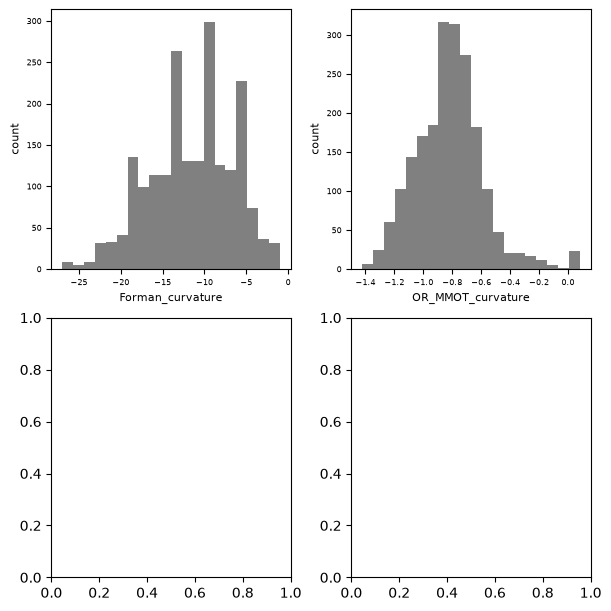

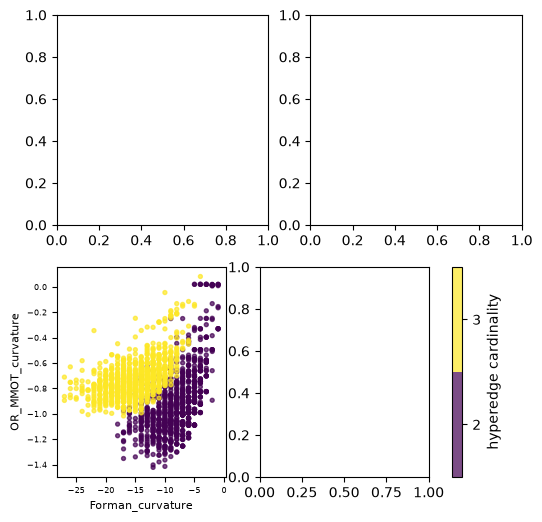

In [108]:
pearson_matrix = pd.DataFrame(index=labels, columns=labels, dtype=float)
spearman_matrix = pd.DataFrame(index=labels, columns=labels, dtype=float)

for i, a in enumerate(labels):
    pearson_matrix.loc[a, a] = spearman_matrix.loc[a, a] = 1.0
    for b in labels[i + 1:]:
        _, _, _, r, rho = correlate(a, b)
        pearson_matrix.loc[a, b] = pearson_matrix.loc[b, a] = r
        spearman_matrix.loc[a, b] = spearman_matrix.loc[b, a] = rho

print("Pearson correlation matrix:")
display(pearson_matrix)
print("\nSpearman correlation matrix:")
display(spearman_matrix)

n = len(labels)
pairs = list(combinations(range(n), 2))

card_all = pd.concat([parsed[l]["cardinality"] for l in labels]).dropna()
vmin, vmax = int(card_all.min()), int(card_all.max())

# Discrete colour mapping: one colour band per integer cardinality
levels = np.arange(vmin, vmax + 2)                 # bin edges as integers
cmap = plt.get_cmap("viridis", vmax - vmin + 1)    # quantized to that many colours
norm = BoundaryNorm(levels - 0.5, cmap.N)          # centre each integer in its band

fig, axes = plt.subplots(2, n, figsize=(3 * n, 6), squeeze=False, layout="constrained")

# Top row: one histogram per measure
for i, a in enumerate(labels):
    ax = axes[0][i]

    values = np.asarray(parsed[a]["value"], dtype=float)
    n_valid = np.count_nonzero(~np.isnan(values))
    print(f"{a}: {n_valid} of {values.size} values are not NaN")

    ax.hist(values, bins=20, color="gray")
    ax.set_xlabel(a, fontsize=8)
    ax.set_ylabel("count", fontsize=8)
    ax.tick_params(labelsize=6)

import itertools

pairs  = list(itertools.combinations(range(len(labels)), 2))
ncols  = max(len(labels), len(pairs))
fig, axes = plt.subplots(2, ncols, figsize=(3.0 * ncols, 6.0), squeeze=False)

# Bottom row: one scatter per pair, coloured by hyperedge cardinality
for k, (i, j) in enumerate(pairs):
    a, b = labels[i], labels[j]
    ax = axes[1][k]
    df = build_pair_dataframe(parsed[a], parsed[b], a, b)
    sc = ax.scatter(df["value_a"], df["value_b"], c=df["cardinality"],
                    cmap=cmap, norm=norm, s=8, alpha=0.7)
    ax.set_xlabel(a, fontsize=8)
    ax.set_ylabel(b, fontsize=8)
    ax.tick_params(labelsize=6)

cbar = fig.colorbar(sc, ax=axes[1, :].tolist(), ticks=np.arange(vmin, vmax + 1),
                    spacing="proportional", label="hyperedge cardinality")
cbar.ax.minorticks_off()
plt.show()

## Same correlations, excluding zero-valued rows

A pair is dropped if *either* file reports (near-)zero for that hyperedge.
`ZERO_TOL = 0.0` drops only exact zeros; raise it to e.g. `1e-8` to also drop
values that are numerically zero (`OR_Dual` has many entries like `1.67e-09`).
Note `n` now differs per pair, so the matrix entries are not on a common sample.

In [109]:
def correlate_defined(name_a: str, name_b: str):
    """As `correlate`, but drops rows where either measure is undefined (NaN)."""
    a, b = resolve_label(name_a), resolve_label(name_b)
    df = build_pair_dataframe(parsed[a], parsed[b], a, b)
    n_all = len(df)

    df = df.dropna(subset=["value_a", "value_b"]).reset_index(drop=True)

    x, y = df["value_a"].to_numpy(), df["value_b"].to_numpy()
    if len(df) < 3 or np.ptp(x) == 0 or np.ptp(y) == 0:
        print(f"  warning: {a} vs {b}: only {len(df)} defined rows")
        return df, a, b, float("nan"), float("nan"), n_all

    return (df, a, b,
            float(stats.pearsonr(x, y).statistic),
            float(stats.spearmanr(x, y).statistic),
            n_all)


def plot_and_correlate_nonzero(name_a: str, name_b: str):
    df, a, b, pearson_r, spearman_r, n_all = correlate_defined(name_a, name_b)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(df["value_a"], df["value_b"], alpha=0.6, edgecolor="k", linewidth=0.3)
    ax.set_xlabel(a)
    ax.set_ylabel(b)
    ax.set_title(f"{a} vs {b}, zeros excluded  (n={len(df)} of {n_all})\n"
                 f"Pearson r={pearson_r:.3f}, Spearman ρ={spearman_r:.3f}")
    plt.tight_layout()
    plt.show()

    return df, pearson_r, spearman_r

In [110]:
pearson_matrix_nz = pd.DataFrame(index=labels, columns=labels, dtype=float)
spearman_matrix_nz = pd.DataFrame(index=labels, columns=labels, dtype=float)
n_matrix_nz = pd.DataFrame(index=labels, columns=labels, dtype=float)

for i, a in enumerate(labels):
    pearson_matrix_nz.loc[a, a] = spearman_matrix_nz.loc[a, a] = 1.0
    n_matrix_nz.loc[a, a] = int((parsed[a]["value"].abs()).sum())
    for b in labels[i + 1:]:
        df, _, _, r, rho, _ = correlate_defined(a, b)
        pearson_matrix_nz.loc[a, b] = pearson_matrix_nz.loc[b, a] = r
        spearman_matrix_nz.loc[a, b] = spearman_matrix_nz.loc[b, a] = rho
        n_matrix_nz.loc[a, b] = n_matrix_nz.loc[b, a] = len(df)

print(f"Pearson (zeros excluded):")
display(pearson_matrix_nz)
print("\nSpearman (zeros excluded):")
display(spearman_matrix_nz)

Pearson (zeros excluded):


,Forman_curvature,OR_MMOT_curvature
Forman_curvature,1.000000,0.074326
OR_MMOT_curvature,0.074326,1.000000



Spearman (zeros excluded):


,Forman_curvature,OR_MMOT_curvature
Forman_curvature,1.000000,-0.021658
OR_MMOT_curvature,-0.021658,1.000000


## Forman vs OR_MMOT, segmented by cardinality

The pooled correlation mixes hyperedges of different sizes. Forman curvature scales
directly with cardinality, so part of any pooled correlation may just be both measures
tracking hyperedge size rather than agreeing about geometry. Correlating within each
cardinality level removes that shared driver: one Pearson/Spearman pair per level.


Forman_curvature vs OR_MMOT_curvature, within each cardinality level:


,n,pearson_r,spearman_rho
cardinality,,,
2,1025,0.591749,0.589428
3,1003,0.530102,0.502093


pooled across all levels: Pearson r=0.074, Spearman rho=-0.022, n=2028


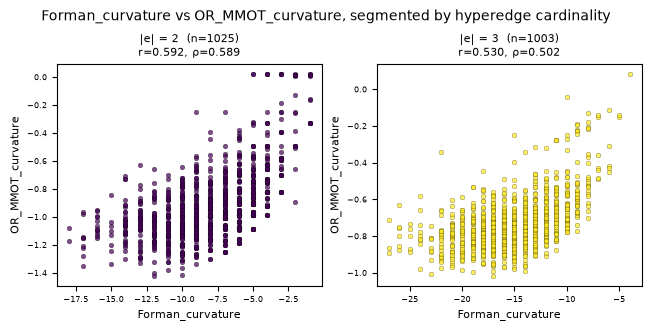

In [111]:
STRAT_A = "Forman_curvature"
STRAT_B = "OR_MMOT_curvature"
MIN_GROUP = 3  # cardinality levels with fewer rows than this get NaN instead of a correlation

sa, sb = resolve_label(STRAT_A), resolve_label(STRAT_B)
df_strat = build_pair_dataframe(parsed[sa], parsed[sb], sa, sb)
df_strat = df_strat.dropna(subset=["value_a", "value_b", "cardinality"])

rows = []
for card, g in df_strat.groupby("cardinality"):
    x, y = g["value_a"].to_numpy(), g["value_b"].to_numpy()
    if len(g) < MIN_GROUP:
        print(f"  cardinality {int(card)}: skipped, only {len(g)} rows")
        r = rho = float("nan")
    elif np.ptp(x) == 0 or np.ptp(y) == 0:
        const = sa if np.ptp(x) == 0 else sb
        print(f"  cardinality {int(card)}: {const} is constant, correlation undefined (n={len(g)})")
        r = rho = float("nan")
    else:
        r = float(stats.pearsonr(x, y).statistic)
        rho = float(stats.spearmanr(x, y).statistic)
    rows.append({"cardinality": int(card), "n": len(g), "pearson_r": r, "spearman_rho": rho})

strat = pd.DataFrame(rows).set_index("cardinality")

# Pooled correlation over all cardinalities, for comparison
_, _, _, r_pooled, rho_pooled = correlate(sa, sb)

print(f"\n{sa} vs {sb}, within each cardinality level:")
display(strat)
print(f"pooled across all levels: Pearson r={r_pooled:.3f}, "
      f"Spearman rho={rho_pooled:.3f}, n={len(df_strat)}")

# One scatter per cardinality level, coloured to match the cardinality colourbar above
cards = strat.index.to_list()
strat_cmap = plt.get_cmap("viridis", len(cards))

ncols = min(len(cards), 4)
nrows = int(np.ceil(len(cards) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.2 * nrows),
                         squeeze=False, layout="constrained")

for k, (ax, card) in enumerate(zip(axes.flat, cards)):
    g = df_strat[df_strat["cardinality"] == card]
    ax.scatter(g["value_a"], g["value_b"], s=12, alpha=0.7,
               color=strat_cmap(k), edgecolor="k", linewidth=0.2)
    ax.set_title(f"|e| = {card}  (n={strat.loc[card, 'n']})\n"
                 f"r={strat.loc[card, 'pearson_r']:.3f}, "
                 f"ρ={strat.loc[card, 'spearman_rho']:.3f}", fontsize=8)
    ax.set_xlabel(sa, fontsize=8)
    ax.set_ylabel(sb, fontsize=8)
    ax.tick_params(labelsize=6)

for ax in axes.flat[len(cards):]:
    ax.set_visible(False)

fig.suptitle(f"{sa} vs {sb}, segmented by hyperedge cardinality", fontsize=10)
plt.show()

In [112]:
res = pd.DataFrame(rows)
valid = res.dropna(subset=["pearson_r"])
weighted_pearson_correlation = (valid["pearson_r"] * valid["n"]).sum() / valid["n"].sum()
print(f"Weighted stratified Pearson correlation: {weighted_pearson_correlation:.4f}")
print(f"pooled over {len(valid)} of {len(res)} strata, {valid['n'].sum()} rows")

valid = res.dropna(subset=["spearman_rho"])
weighted_pearson_correlation = (valid["spearman_rho"] * valid["n"]).sum() / valid["n"].sum()
print(f"Weighted stratified Spearman correlation: {weighted_pearson_correlation:.4f}")
print(f"pooled over {len(valid)} of {len(res)} strata, {valid['n'].sum()} rows")

Weighted stratified Pearson correlation: 0.5613
pooled over 2 of 2 strata, 2028 rows
Weighted stratified Spearman correlation: 0.5462
pooled over 2 of 2 strata, 2028 rows


In [113]:
'''
Two tables, of Pearson and Spearman
each one with entries of:
1. raw correlation between MMOT and Forman
2. stratified correlation MMOT, Forman (so for cardinalities of 2,3,4 like (0.3,0.4,0.5))
3. stratified weighted correlation (cell above)
4. OR_MMOT v OR_Dual correlation (on non-zero cells)
'''

FORMAN = "Forman_curvature"
MMOT   = "OR_MMOT_curvature"
# DUAL   = "OR_Dual_curvature"

fF, fM = resolve_label(FORMAN), resolve_label(MMOT)

# (1) raw / pooled Forman vs MMOT
df_raw, _, _, r_raw, rho_raw = correlate(fF, fM)

# (2) stratified by cardinality: reuse `strat` if cell 16 ran on this pair
if "strat" in globals() and {sa, sb} == {fF, fM}:
    strat_tbl = strat
else:
    _df = (build_pair_dataframe(parsed[fF], parsed[fM], fF, fM)
             .dropna(subset=["value_a", "value_b", "cardinality"]))
    _rows = []
    for card, g in _df.groupby("cardinality"):
        x, y = g["value_a"].to_numpy(), g["value_b"].to_numpy()
        ok = len(g) >= 3 and np.ptp(x) > 0 and np.ptp(y) > 0
        _rows.append({
            "cardinality": int(card), "n": len(g),
            "pearson_r":    float(stats.pearsonr(x, y).statistic)  if ok else float("nan"),
            "spearman_rho": float(stats.spearmanr(x, y).statistic) if ok else float("nan"),
        })
    strat_tbl = pd.DataFrame(_rows).set_index("cardinality")

# (4) MMOT vs Dual, undefined (NaN) rows dropped
#df_def, _, _, r_def, rho_def, n_def_all = correlate_defined(fM, fD)


def summary_table(stat: str) -> pd.DataFrame:
    """stat: 'pearson' or 'spearman'."""
    col = {"pearson": "pearson_r", "spearman": "spearman_rho"}[stat]
    raw = {"pearson": r_raw,  "spearman": rho_raw}[stat]
    #dfn = {"pearson": r_def,  "spearman": rho_def}[stat]

    valid = strat_tbl.dropna(subset=[col])                       # (3) n-weighted mean
    weighted = (valid[col] * valid["n"]).sum() / valid["n"].sum()

    out = [{"comparison": f"{fF} vs {fM}", "subset": "all hyperedges (pooled)",
            "n": len(df_raw), "value": raw}]
    out += [{"comparison": f"{fF} vs {fM}", "subset": f"|e| = {int(c)}",
             "n": int(row["n"]), "value": row[col]}
            for c, row in strat_tbl.iterrows()]
    out.append({"comparison": f"{fF} vs {fM}", "subset": "stratified, n-weighted",
                "n": int(valid["n"].sum()), "value": weighted})
    # out.append({"comparison": f"{fM} vs {fD}", "subset": f"NaN dropped (of {n_def_all})",
    #            "n": len(df_def), "value": dfn})

    label = "Pearson r" if stat == "pearson" else "Spearman rho"
    return (pd.DataFrame(out)
              .rename(columns={"value": label})
              .set_index(["comparison", "subset"]))


pearson_summary  = summary_table("pearson")
spearman_summary = summary_table("spearman")

print("=== Pearson ===")
display(pearson_summary.round(4))
print("\n=== Spearman ===")
display(spearman_summary.round(4))

=== Pearson ===


n  Pearson r
comparison                            subset                                  
Forman_curvature vs OR_MMOT_curvature all hyperedges (pooled)  2028     0.0743
                                      |e| = 2                  1025     0.5917
                                      |e| = 3                  1003     0.5301
                                      stratified, n-weighted   2028     0.5613


=== Spearman ===


n  \
comparison                            subset                          
Forman_curvature vs OR_MMOT_curvature all hyperedges (pooled)  2028   
                                      |e| = 2                  1025   
                                      |e| = 3                  1003   
                                      stratified, n-weighted   2028   

                                                               Spearman rho  
comparison                            subset                                 
Forman_curvature vs OR_MMOT_curvature all hyperedges (pooled)       -0.0217  
                                      |e| = 2                        0.5894  
                                      |e| = 3                        0.5021  
                                      stratified, n-weighted         0.5462

Correlation with hyperedge degree (cardinality):


,n,pearson_r,spearman_rho
measure,,,
Forman_curvature,2028,-0.6966,-0.7165
OR_MMOT_curvature,2028,0.3973,0.4843


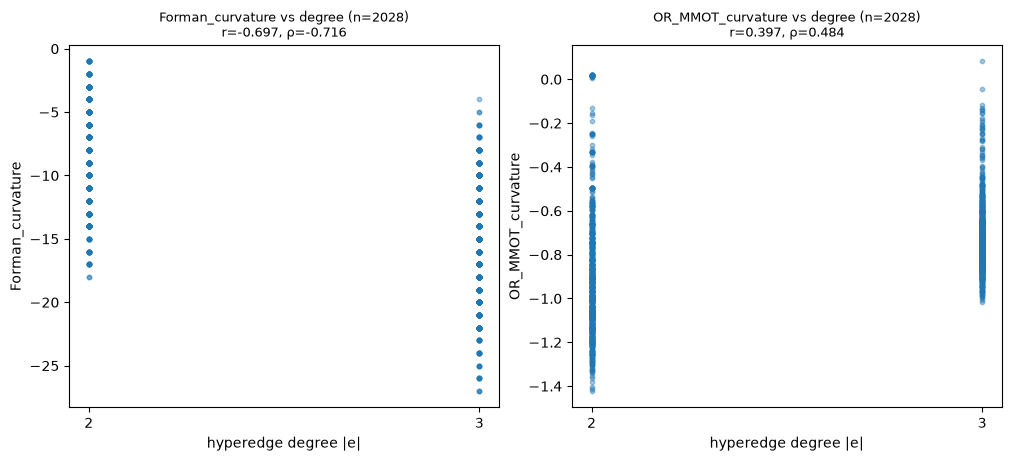

In [114]:
# Correlation of each curvature measure with hyperedge degree (cardinality)
DEGREE_TARGETS = ["Forman_curvature", "OR_MMOT_curvature"]

deg_rows = []
for name in DEGREE_TARGETS:
    lab = resolve_label(name)
    d = parsed[lab].dropna(subset=["value", "cardinality"])
    x = d["cardinality"].to_numpy(dtype=float)   # degree = number of nodes in the hyperedge
    y = d["value"].to_numpy(dtype=float)

    if len(d) < 3 or np.ptp(x) == 0 or np.ptp(y) == 0:
        print(f"  warning: {lab} vs degree: n={len(d)}, constant input; correlation undefined")
        r = rho = float("nan")
    else:
        pear = stats.pearsonr(x, y)
        spear = stats.spearmanr(x, y)
        r = float(pear.statistic)
        rho = float(spear.statistic)

    deg_rows.append({"measure": lab, "n": len(d),
                     "pearson_r": r,
                     "spearman_rho": rho})

degree_corr = pd.DataFrame(deg_rows).set_index("measure")
print("Correlation with hyperedge degree (cardinality):")
display(degree_corr.round(4))

# Scatter: curvature vs degree, one panel per measure
fig, axes = plt.subplots(1, len(DEGREE_TARGETS), figsize=(5 * len(DEGREE_TARGETS), 4.5),
                         squeeze=False, layout="constrained")
for ax, name in zip(axes[0], DEGREE_TARGETS):
    lab = resolve_label(name)
    d = parsed[lab].dropna(subset=["value", "cardinality"])
    ax.scatter(d["cardinality"], d["value"], s=10, alpha=0.4)
    ax.set_xlabel("hyperedge degree |e|")
    ax.set_ylabel(lab)
    ax.set_xticks(sorted(d["cardinality"].unique().astype(int)))
    ax.set_title(f"{lab} vs degree (n={len(d)})\n"
                 f"r={degree_corr.loc[lab, 'pearson_r']:.3f}, "
                 f"ρ={degree_corr.loc[lab, 'spearman_rho']:.3f}", fontsize=9)
plt.show()
